In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df =pd.read_csv('C:/Users/Lenovo/Downloads/college_sleep_and_gpa.csv')

In [ ]:
df.head()

,student_id,study,university,semester,cohort_code,gender,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,...,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep,sleep_bracket,sleep_midpoint_clock
0,293,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,370.0,6.17,...,0.0500,0.931,4.00,3.76,-0.24,49.0,0.112,0,6-6.5h,07:20
1,294,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,406.8,6.78,...,0.0476,0.862,4.00,3.55,-0.45,49.0,0.112,0,6.5-7h,05:00
2,297,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,253.8,4.23,...,0.1639,0.586,3.00,3.59,0.59,46.0,-0.604,1,<5.5h,05:38
3,303,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,411.9,6.86,...,0.7854,0.931,3.80,3.46,-0.34,39.0,-2.275,0,6.5-7h,07:52
4,304,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,408.1,6.80,...,0.1538,0.931,3.17,3.50,0.33,39.0,-2.275,0,6.5-7h,04:54


In [ ]:
df.describe()

,student_id,study,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,daytime_sleep_minutes,sleep_midpoint_minutes,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep
count,634.000000,634.000000,630.000000,633.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,487.000000,487.000000,634.000000
mean,13005.892744,3.181388,0.166667,0.187994,397.324763,6.622098,41.165615,398.678707,0.451687,0.867478,3.465584,3.449587,-0.015997,29.392197,-0.000057,0.208202
std,26496.593477,1.317125,0.377213,0.391016,50.855641,0.847741,27.388294,72.712017,1.393631,0.178999,0.437578,0.500463,0.403109,17.642780,1.000017,0.406343
min,1.000000,1.000000,0.000000,0.000000,194.800000,3.250000,2.300000,247.100000,0.004500,0.214000,1.210000,0.350000,-1.877000,5.000000,-3.983000,0.000000
25%,178.000000,2.000000,0.000000,0.000000,366.950000,6.112500,23.100000,345.175000,0.074700,0.821000,3.232250,3.233000,-0.189500,15.000000,-0.551000,0.000000
50%,358.500000,3.000000,0.000000,0.000000,400.350000,6.675000,35.000000,388.250000,0.135000,0.932000,3.558000,3.556000,0.000000,17.000000,0.041000,0.000000
75%,592.750000,4.000000,0.000000,0.000000,430.100000,7.170000,51.250000,437.625000,0.291700,1.000000,3.789500,3.810000,0.193750,48.000000,0.560000,0.000000
max,99978.000000,5.000000,2.000000,1.000000,587.700000,9.790000,292.300000,724.700000,20.849200,1.000000,4.000000,4.000000,1.332000,73.000000,4.055000,1.000000


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               634 non-null    int64  
 1   study                    634 non-null    int64  
 2   university               634 non-null    str    
 3   semester                 634 non-null    str    
 4   cohort_code              634 non-null    str    
 5   gender                   631 non-null    str    
 6   first_generation         630 non-null    float64
 7   underrepresented         633 non-null    float64
 8   avg_sleep_minutes        634 non-null    float64
 9   avg_sleep_hours          634 non-null    float64
 10  daytime_sleep_minutes    634 non-null    float64
 11  sleep_midpoint_minutes   634 non-null    float64
 12  bedtime_variability      634 non-null    float64
 13  nights_tracked_fraction  634 non-null    float64
 14  prior_gpa                634 non-null

By seeing the describtion and the info of the data ,decided i will use regression to predict the term_gpa by training the other features, first we have to do preprocessing and fill or drop the null values, then encoding and scaling 

<Axes: xlabel='term_gpa', ylabel='Count'>

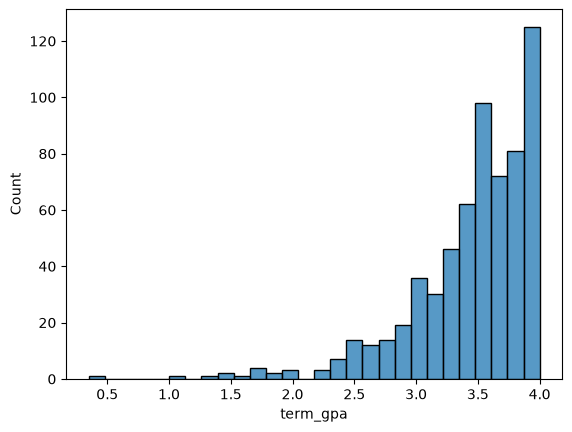

In [ ]:
sns.histplot(df['term_gpa'])

<Axes: xlabel='prior_gpa', ylabel='Count'>

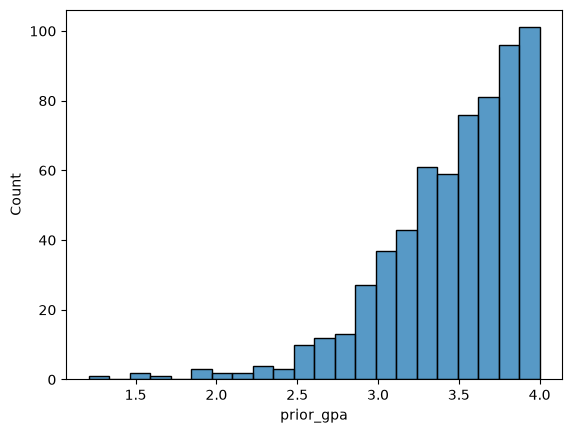

In [ ]:
sns.histplot(df['prior_gpa'])

<Axes: xlabel='avg_sleep_hours', ylabel='prior_gpa'>

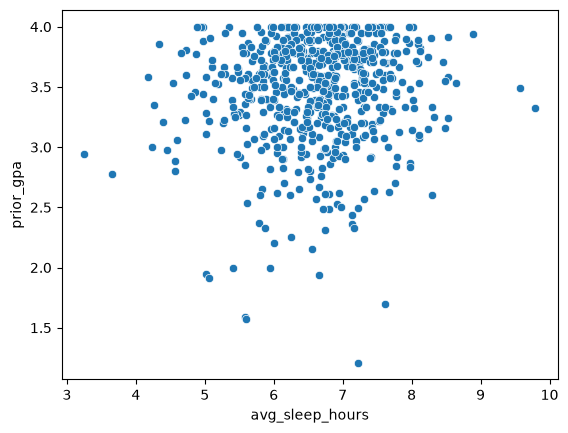

In [ ]:
sns.scatterplot(x=df['avg_sleep_hours'],y=df['prior_gpa'])

<Axes: xlabel='avg_sleep_hours', ylabel='term_gpa'>

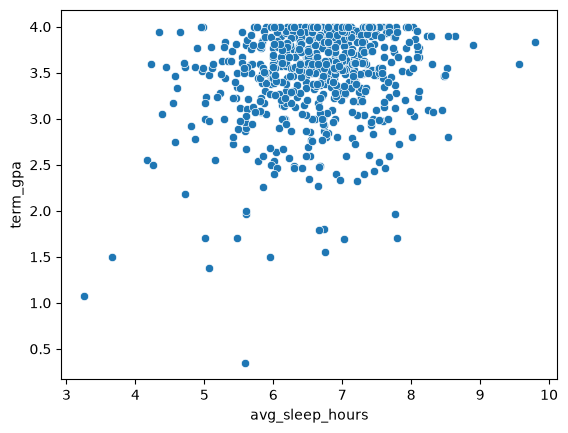

In [ ]:
sns.scatterplot(x=df['avg_sleep_hours'],y=df['term_gpa'])

In [ ]:
df['first_generation']=df['first_generation'].fillna(df['first_generation'].mode()[0])
df['term_units']=df['term_units'].fillna(df['term_units'].mean())
df['term_load_z']=df['term_load_z'].fillna(df['term_load_z'].mean())
df=df.dropna()

In [ ]:
X = df.drop(['term_gpa', 'gpa_change', 'student_id'], axis=1)
y=df['term_gpa']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2, random_state=20)

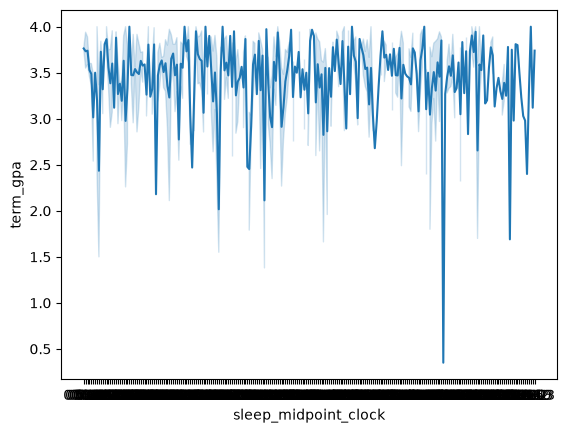

In [ ]:
sns.lineplot(x='sleep_midpoint_clock',y='term_gpa',data=df)
df=df.drop('sleep_midpoint_clock',axis=1)

In [ ]:
df.columns

Index(['student_id', 'study', 'university', 'semester', 'cohort_code',
       'gender', 'first_generation', 'underrepresented', 'avg_sleep_minutes',
       'avg_sleep_hours', 'daytime_sleep_minutes', 'sleep_midpoint_minutes',
       'bedtime_variability', 'nights_tracked_fraction', 'prior_gpa',
       'term_gpa', 'gpa_change', 'term_units', 'term_load_z', 'under_6h_sleep',
       'sleep_bracket'],
      dtype='str')

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

encoder = OneHotEncoder(handle_unknown='ignore')
scalar = StandardScaler()

preprocessor = ColumnTransformer([
    ('num', scalar, [ 'study','first_generation', 'underrepresented', 'avg_sleep_minutes',
       'avg_sleep_hours', 'daytime_sleep_minutes', 'sleep_midpoint_minutes',
       'bedtime_variability', 'nights_tracked_fraction', 'prior_gpa',
         'term_units', 'term_load_z', 'under_6h_sleep',]),
    
    ('cat', encoder, ['university', 'semester', 'cohort_code', 'gender', 'sleep_bracket'])
    
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
y_train_scaled= scalar.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled=scalar.transform(y_test.values.reshape(-1, 1))


In [ ]:
#first model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
model1= LinearRegression()
model1.fit(X_train_processed,y_train_scaled)
predictions = model1.predict(X_test_processed)


print("R2",r2_score(y_test_scaled, predictions))
print("RSME",np.sqrt(mean_squared_error(y_test_scaled, predictions)))   # RMSE


baseline_value = y_train_scaled.mean()
baseline_predictions = np.full_like(y_test_scaled, baseline_value)
baseline_rmse = np.sqrt(mean_squared_error(y_test_scaled, baseline_predictions))
print("baseline RSME",baseline_rmse)


R2 0.4265533924100121
RSME 0.718793142463757
baseline RSME 0.9625270714129502


Linear regression model
The R2 explain 42% of the varience in the target column wich tells that the model is performing not good enough and can't predict every unseen values
The RSME tells that the error is big and it have a  diffrence in comparasion with the baseline RSME so it does not predict the average most of time it had learned somthing useful and can predict some correct values

In [ ]:
# second model
from sklearn.tree import DecisionTreeRegressor
model2= DecisionTreeRegressor(max_depth=5)
model2.fit(X_train_processed,y_train_scaled)
predictions2=model2.predict(X_test_processed)
print("R2",r2_score(y_test_scaled, predictions2))
print("RSME",np.sqrt(mean_squared_error(y_test_scaled, predictions2))) 
print("baseline RSME",baseline_rmse)



R2 0.08940375880355467
RSME 0.9057750587005104
baseline RSME 0.9625270714129502


Desicion Tree
 R² 0.09, meaning the model now explains a small amount of the variance in term_gpa
  The RMSE  0.91, just below the baseline RMSE of 0.96 — a slight 
improvement, but still far weaker than Linear Regression's RMSE of 0.72.

This confirms that the Linear Regression model is better for this data set